In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import torch

def power_of_matrix(A, n):
    """
    Calculate A^n with A matrix
    """
    if n == 0:
        res = np.eye(A.shape[0])
        return res
    res = A
    while n > 1:
        res = res @ A
        n -= 1
    return res

def solution(U):
    # find the eigenvalues and eigenvector of U(transpose).U
    e_vals, e_vecs = np.linalg.eig(np.dot(U.T, U))
    # extract the eigenvector (column) associated with the minimum eigenvalue
    return e_vecs[:, np.argmin(e_vals)]

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\bpjam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [22]:
# Value function for classical market making problem, calculate v(., T) / T
Time = np.arange(50, 950, 10)

dt = 1
# Posted LO is filled with probability of e^(-kappa*depth)
kappa_sell , kappa_buy = 10**1 , 10**1
assert kappa_buy == kappa_sell
kappa = kappa_sell
# Arrival rate of selling MOs from other participants in market
lambda_sell = 1
# Arrival rate of buying MOs from other participants in market
lambda_buy = 1
# Inventory boundary
q_upper = 30
q_lower = -30
# Risk aversion parameters
alpha = 0
phi = 1*10**-5

sigma = 0.05


X0 = 0
S0 = 10

# Let A denote a square matrix
A = np.zeros([q_upper-q_lower+1, q_upper-q_lower+1])
z = np.zeros(q_upper-q_lower+1)
# w = np.zeros([length, q_upper - q_lower + 1])
# optimal_depth_bid = np.zeros([length, q_upper - q_lower])
# optimal_depth_ask = np.zeros([length, q_upper - q_lower])

# Notice we assume kappa_buy = kappa_sell in the model
# i denotes the column number
for i in range(q_upper-q_lower+1):
    # j denotes the row number
    for j in range(q_upper-q_lower+1):
        if j == i:
            # q = q_upper - j
            A[j,i] = - phi*kappa*(q_upper-j)**2
        elif j == i-1:
            A[j,i] = lambda_buy*np.e**(-1)
        elif j == i+1:
            A[j,i] = lambda_sell*np.e**(-1)

for i in range(q_upper-q_lower+1):
    # q = q_upper - i
    z[i] = np.exp(-alpha*kappa*(q_upper-i)**2)

In [23]:
Q_initial = [-15, -10, -5, 0, 4, 8, 12]

value_over_t = []

for Q0 in Q_initial:
    value_over_t_q0 = []
    for T in Time:
        t =np.arange(0, T+dt, dt)
        length = len(t)

        h = np.zeros([length , q_upper-q_lower+1])
        delta_buy = np.zeros([length , q_upper-q_lower])
        delta_sell = np.zeros([length , q_upper-q_lower])

        for i in range(length):
            h[i] = np.log(np.dot(expm(A*(T-i*dt)),z))/kappa

        for j in range(q_upper-q_lower):
            # q = q_upper - j
            delta_sell[:,j] = 1/kappa + h[:,j] - h[:,j+1]

        for j in range(q_upper-q_lower):
            # q = q_upper -1 - j
            delta_buy[:,j] = 1/kappa + h[:,j+1] - h[:,j]

        theo_value_function = h[0,int(q_upper - Q0)]
        value_over_t_q0.append(theo_value_function / T)
    value_over_t.append(value_over_t_q0)

In [24]:
# Let see whether A is diagonalizable
import scipy.linalg

evalues, evectors = scipy.linalg.eig(A)
Tau = np.zeros((len(evalues), len(evalues)))

for i in range(len(evalues)):
    Tau[i, i] = np.real(evalues[i])

gamma = np.real(max(evalues)) / kappa_sell

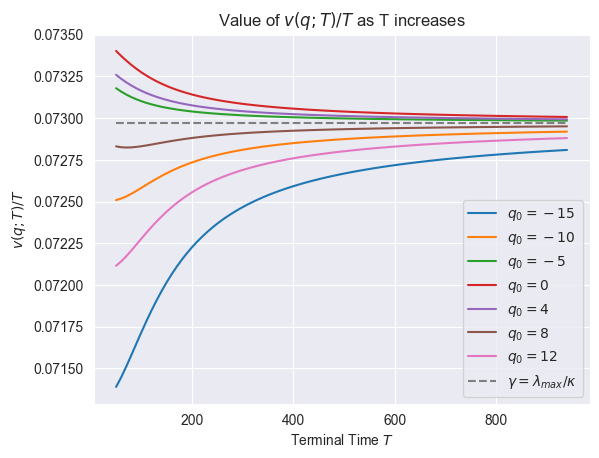

In [25]:
for i in range(len(Q_initial)):
    plt.plot(Time, value_over_t[i], label=f"$q_0={Q_initial[i]}$")
plt.plot(Time, [gamma for i in Time], '--', label='$\gamma = \lambda_{max} / \kappa$')
plt.xlabel("Terminal Time $T$")
plt.ylabel("$v(q; T) / T$")
plt.title("Value of $v(q; T) / T$ as T increases")
plt.legend()
plt.show()

## Numerically solve the ergodic control problem

In [26]:
# Let C denote a square matrix
C = np.zeros([q_upper-q_lower+1, q_upper-q_lower+1])

# Notice we assume kappa_buy = kappa_sell in the model
# i denotes the column number
for i in range(q_upper-q_lower+1):
    # j denotes the row number
    for j in range(q_upper-q_lower+1):
        if j == i:
            # q = q_upper - j
            C[j,i] = - kappa*(phi*(q_upper-j)**2 + gamma)
        elif j == i-1:
            C[j,i] = lambda_buy*np.e**(-1)
        elif j == i+1:
            C[j,i] = lambda_sell*np.e**(-1)

In [27]:
print("The shape of coefficient matrix is:", C.shape)
print("The rank of coefficient matrix is:", np.linalg.matrix_rank(C))
print("Therefore, there will be non-trivial solution of v(q)")
print("Since the rank of coefficient matrix is n-1, so the solution must be unique up to a constant")

The shape of coefficient matrix is: (61, 61)
The rank of coefficient matrix is: 60
Therefore, there will be non-trivial solution of v(q)
Since the rank of coefficient matrix is n-1, so the solution must be unique up to a constant


In [32]:
import torch
Q = torch.arange(q_lower,q_upper+1,1).type(torch.float)
Q = Q.reshape(-1,1)
Q = Q.detach().cpu().numpy()

solu1 = -1 * solution(C)
solu2 = -5 * solution(C)
solu3 = -10 * solution(C)

plt.plot(Q.flatten(), np.log(solu1)/kappa, label='solution 1')
plt.plot(Q.flatten(), np.log(solu2)/kappa, label='solution 2')
plt.plot(Q.flatten(), np.log(solu3)/kappa, label='solution 3')

plt.legend()
plt.xlabel("q")
plt.ylabel("value")
plt.title("Solutions $\hat{v}(q)$ to Ergodic HJB Equation")
plt.show()

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\bpjam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [29]:
solu2 = np.log(solu2)/kappa

delta_buy = np.zeros(q_upper - q_lower)
delta_sell = np.zeros(q_upper - q_lower)

for i in range(1, q_upper-q_lower+1):
    delta_sell[i-1] = 1/kappa_buy - solu2[i-1] + solu2[i]
for i in range(q_upper-q_lower):
    delta_buy[i] = 1/kappa_buy + solu2[i] - solu2[i+1]

NameError: name 'solu2' is not defined

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_156/955668474.py:4: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Offset(depth) $\delta$')
/tmp/ipykernel_156/955668474.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Optimal Strategy $\psi^{\pm}(q)$ for Ergodic Control Problem")


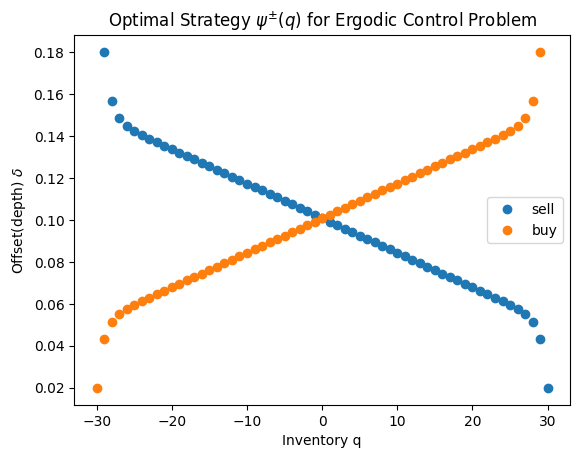

In [11]:
plt.plot(Q.flatten()[1:], delta_sell, 'o',label='sell')
plt.plot(Q.flatten()[:-1], delta_buy, 'o',label='buy')
plt.xlabel("Inventory q")
plt.ylabel('Offset(depth) $\delta$')
plt.title("Optimal Strategy $\psi^{\pm}(q)$ for Ergodic Control Problem")
plt.legend()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_156/1022313784.py:6: SyntaxWarning: invalid escape sequence '\g'
  axes[0].plot(Time, [gamma for _ in Time], '--', label='$\gamma = \lambda_{max} / \kappa$')
/tmp/ipykernel_156/1022313784.py:26: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title("Solutions $\hat{v}(q)$ to Ergodic HJB Equation")
/tmp/ipykernel_156/1022313784.py:33: SyntaxWarning: invalid escape sequence '\d'
  axes[2].set_ylabel("Offset(depth) $\delta$")
/tmp/ipykernel_156/1022313784.py:34: SyntaxWarning: invalid escape sequence '\p'
  axes[2].set_title("Optimal Strategy $\psi^{\pm}(q)$ for Erg

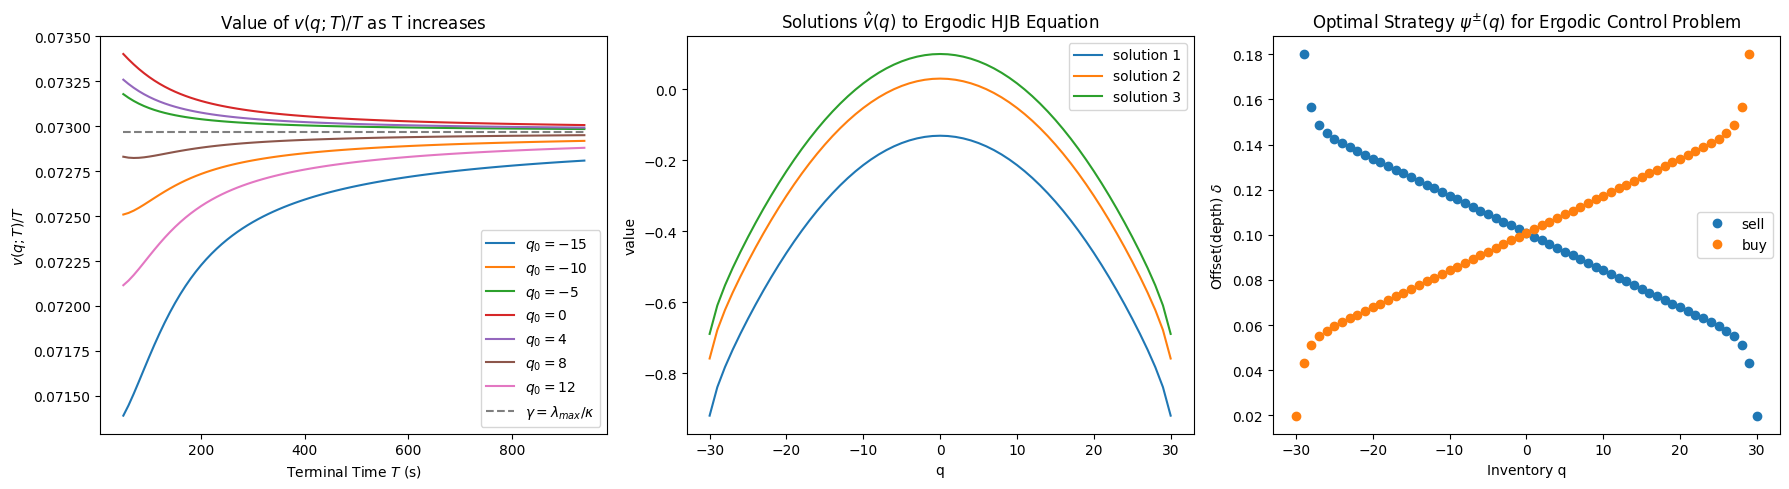

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

# --- Plot 1: Normalised Value over Time ---
for i in range(len(Q_initial)):
    axes[0].plot(Time, value_over_t[i], label=f"$q_0={Q_initial[i]}$")
axes[0].plot(Time, [gamma for _ in Time], '--', label='$\gamma = \lambda_{max} / \kappa$')
axes[0].set_xlabel("Terminal Time $T$ (s)")
axes[0].set_ylabel("$v(q; T) / T$")
axes[0].set_title("Value of $v(q; T) / T$ as T increases")
axes[0].legend()

# --- Plot 2: Solutions to Ergodic HJB Equation ---
Q = torch.arange(q_lower, q_upper + 1, 1).type(torch.float)
Q = Q.reshape(-1, 1)
Q = Q.detach().cpu().numpy()

solu1 = -1 * solution(C)
solu2 = -5 * solution(C)
solu3 = -10 * solution(C)

axes[1].plot(Q.flatten(), np.log(solu1)/kappa, label='solution 1')
axes[1].plot(Q.flatten(), np.log(solu2)/kappa, label='solution 2')
axes[1].plot(Q.flatten(), np.log(solu3)/kappa, label='solution 3')
axes[1].set_xlabel("q")
axes[1].set_ylabel("value")
axes[1].set_title("Solutions $\hat{v}(q)$ to Ergodic HJB Equation")
axes[1].legend()

# --- Plot 3: Optimal Strategy ---
axes[2].plot(Q.flatten()[1:], delta_sell, 'o', label='sell')
axes[2].plot(Q.flatten()[:-1], delta_buy, 'o', label='buy')
axes[2].set_xlabel("Inventory q")
axes[2].set_ylabel("Offset(depth) $\delta$")
axes[2].set_title("Optimal Strategy $\psi^{\pm}(q)$ for Ergodic Control Problem")
axes[2].legend()

plt.tight_layout()


#plt.savefig("/Users/galen/Desktop/ergodic_sim.pdf", format='pdf', bbox_inches='tight')
plt.show()
plt.close()


## Ergodicity

In [21]:
T_exp = 2000
ts_size_exp = 0.1
ts_exp = np.arange(0, T_exp + ts_size_exp, ts_size_exp)

Cash_exp = []
Inventory_exp = []
Midprice_exp = []

length_exp = len(ts_exp)

for _ in range(5000):
    X_exp = np.zeros(length_exp)
    Q_exp = np.zeros(length_exp)
    S_exp = np.zeros(length_exp)
    dW_exp = np.sqrt(ts_size_exp) * np.random.randn(length_exp - 1)

    X_exp[0] = 0
    Q_exp[0] = 0
    S_exp[0] = S0

    for i in range(length_exp - 1):
        S_exp[i+1] = S_exp[i] + sigma * dW_exp[i]

        q_exp = int(Q_exp[i])

        delta_sell_exp = 1e20 if q_exp <= q_lower else float(delta_sell[q_upper + q_exp - 1])
        delta_buy_exp  = 1e20 if q_exp >= q_upper else float(delta_buy[q_upper + q_exp])

        dN_sell_exp = np.random.poisson(lambda_buy * np.exp(-kappa * delta_sell_exp) * ts_size_exp)
        dN_buy_exp  = np.random.poisson(lambda_sell * np.exp(-kappa * delta_buy_exp) * ts_size_exp)

        X_exp[i+1] = X_exp[i] + (S_exp[i] + delta_sell_exp) * dN_sell_exp - (S_exp[i] - delta_buy_exp) * dN_buy_exp
        Q_exp[i+1] = Q_exp[i] + dN_buy_exp - dN_sell_exp

    Cash_exp.append(X_exp)
    Inventory_exp.append(Q_exp)
    Midprice_exp.append(S_exp)

Cash_exp = np.array(Cash_exp)
inv_exp = np.array(Inventory_exp)
Midprice_exp = np.array(Midprice_exp)

mtm_exp = Cash_exp + inv_exp * Midprice_exp

TypeError: only length-1 arrays can be converted to Python scalars

In [14]:
T_log = 2000
ts_size_log = 0.1
ts_log = np.arange(0, T_log + ts_size_log, ts_size_log)

a_log = -2
b_log = 10

Cash_log = []
Inventory_log = []
Midprice_log = []

length_log = len(ts_log)

for _ in range(5000):
    X_log = np.zeros(length_log)
    Q_log = np.zeros(length_log)
    S_log = np.zeros(length_log)
    dW_log = np.sqrt(ts_size_log) * np.random.randn(length_log - 1)

    X_log[0] = 0
    Q_log[0] = 0
    S_log[0] = S0

    for i in range(length_log - 1):
        S_log[i+1] = S_log[i] + sigma * dW_log[i]

        q_clipped_log = np.clip(int(Q_log[i]), q_lower, q_upper)

        delta_sell_log = 1e20 if q_clipped_log <= q_lower else float(delta_sell[q_upper + q_clipped_log - 1])
        delta_buy_log  = 1e20 if q_clipped_log >= q_upper else float(delta_buy[q_upper + q_clipped_log])

        if delta_sell_log > 1e10:
            sell_rate_log = 0.0
        else:
            sell_rate_log = float(lambda_buy / (1 + np.exp(a_log + b_log * delta_sell_log)))

        if delta_buy_log > 1e10:
            buy_rate_log = 0.0
        else:
            buy_rate_log = float(lambda_sell / (1 + np.exp(a_log + b_log * delta_buy_log)))

        dN_sell_log = np.random.poisson(sell_rate_log * ts_size_log)
        dN_buy_log  = np.random.poisson(buy_rate_log * ts_size_log)

        X_log[i+1] = X_log[i] + (S_log[i] + delta_sell_log) * dN_sell_log - (S_log[i] - delta_buy_log) * dN_buy_log
        Q_log[i+1] = Q_log[i] + dN_buy_log - dN_sell_log

    Cash_log.append(X_log)
    Inventory_log.append(Q_log)
    Midprice_log.append(S_log)

Cash_log = np.array(Cash_log)
inv_log = np.array(Inventory_log)
Midprice_log = np.array(Midprice_log)

mtm_log = Cash_log + inv_log * Midprice_log

TypeError: only length-1 arrays can be converted to Python scalars

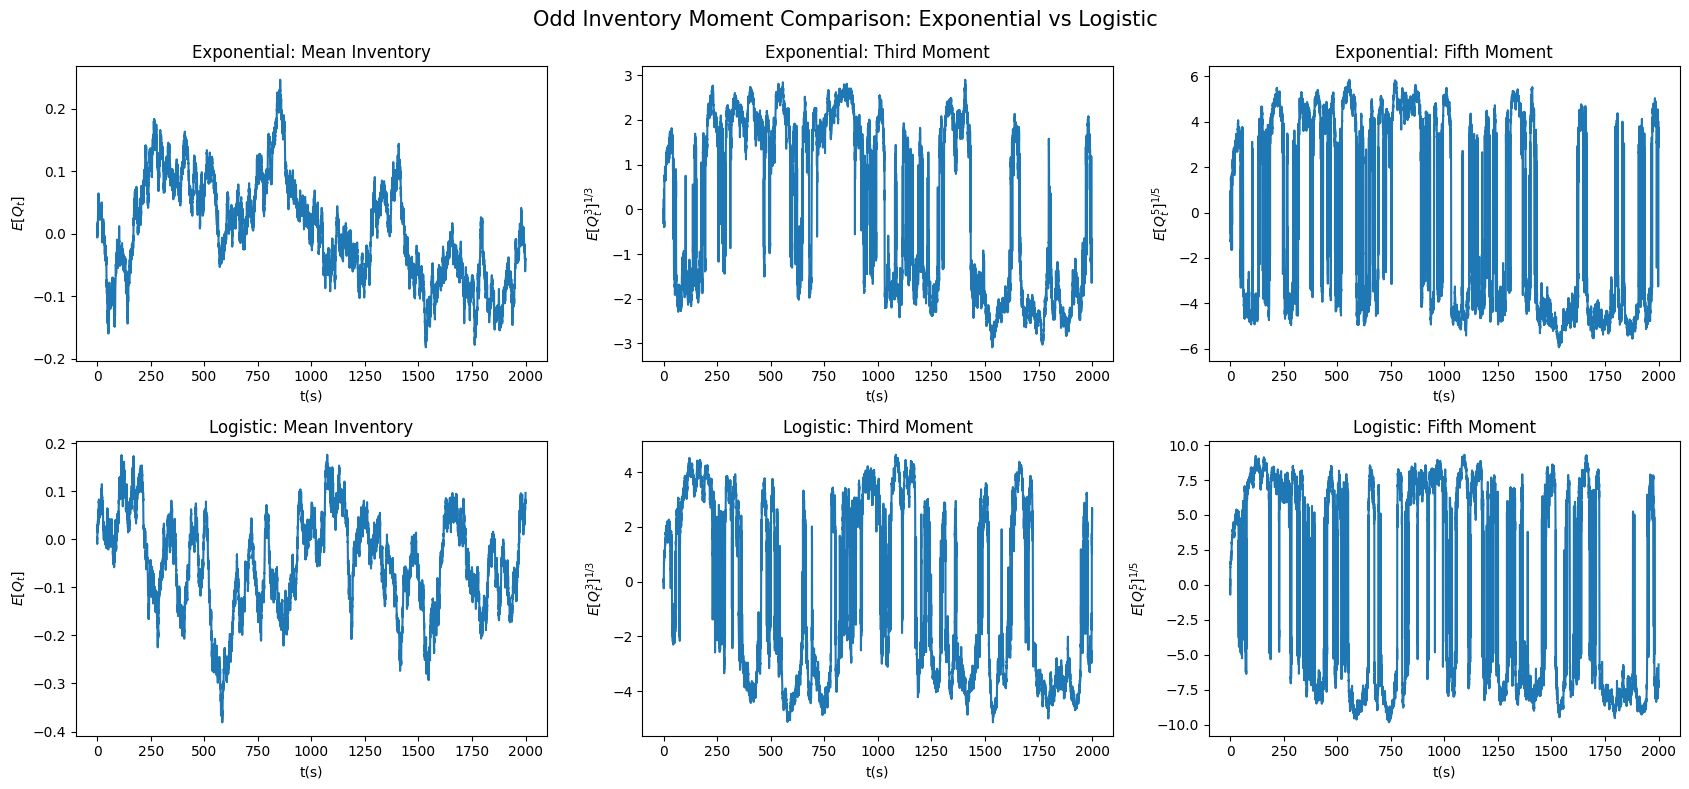

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(17,8))

ax[0, 0].plot(ts_exp, np.mean(inv_exp, axis=0))
ax[0, 0].set_xlabel("t(s)")
ax[0, 0].set_ylabel(r"$E[Q_t]$")
ax[0, 0].set_title("Exponential: Mean Inventory")

m3_exp = np.mean(inv_exp**3, axis=0)
ax[0, 1].plot(ts_exp, np.sign(m3_exp) * (np.abs(m3_exp)) ** (1 / 3))
ax[0, 1].set_xlabel("t(s)")
ax[0, 1].set_ylabel(r"$E[Q_t^3]^{1/3}$")
ax[0, 1].set_title("Exponential: Third Moment")

m5_exp = np.mean(inv_exp**5, axis=0)
ax[0, 2].plot(ts_exp, np.sign(m5_exp) * (np.abs(m5_exp)) ** (1 / 5))
ax[0, 2].set_xlabel("t(s)")
ax[0, 2].set_ylabel(r"$E[Q_t^5]^{1/5}$")
ax[0, 2].set_title("Exponential: Fifth Moment")

ax[1, 0].plot(ts_log, np.mean(inv_log, axis=0))
ax[1, 0].set_xlabel("t(s)")
ax[1, 0].set_ylabel(r"$E[Q_t]$")
ax[1, 0].set_title("Logistic: Mean Inventory")

m3_log = np.mean(inv_log**3, axis=0)
ax[1, 1].plot(ts_log, np.sign(m3_log) * (np.abs(m3_log)) ** (1 / 3))
ax[1, 1].set_xlabel("t(s)")
ax[1, 1].set_ylabel(r"$E[Q_t^3]^{1/3}$")
ax[1, 1].set_title("Logistic: Third Moment")

m5_log = np.mean(inv_log**5, axis=0)
ax[1, 2].plot(ts_log, np.sign(m5_log) * (np.abs(m5_log)) ** (1 / 5))
ax[1, 2].set_xlabel("t(s)")
ax[1, 2].set_ylabel(r"$E[Q_t^5]^{1/5}$")
ax[1, 2].set_title("Logistic: Fifth Moment")

fig.suptitle("Odd Inventory Moment Comparison: Exponential vs Logistic", fontsize=15)

plt.tight_layout()
plt.savefig("Odd_moments_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


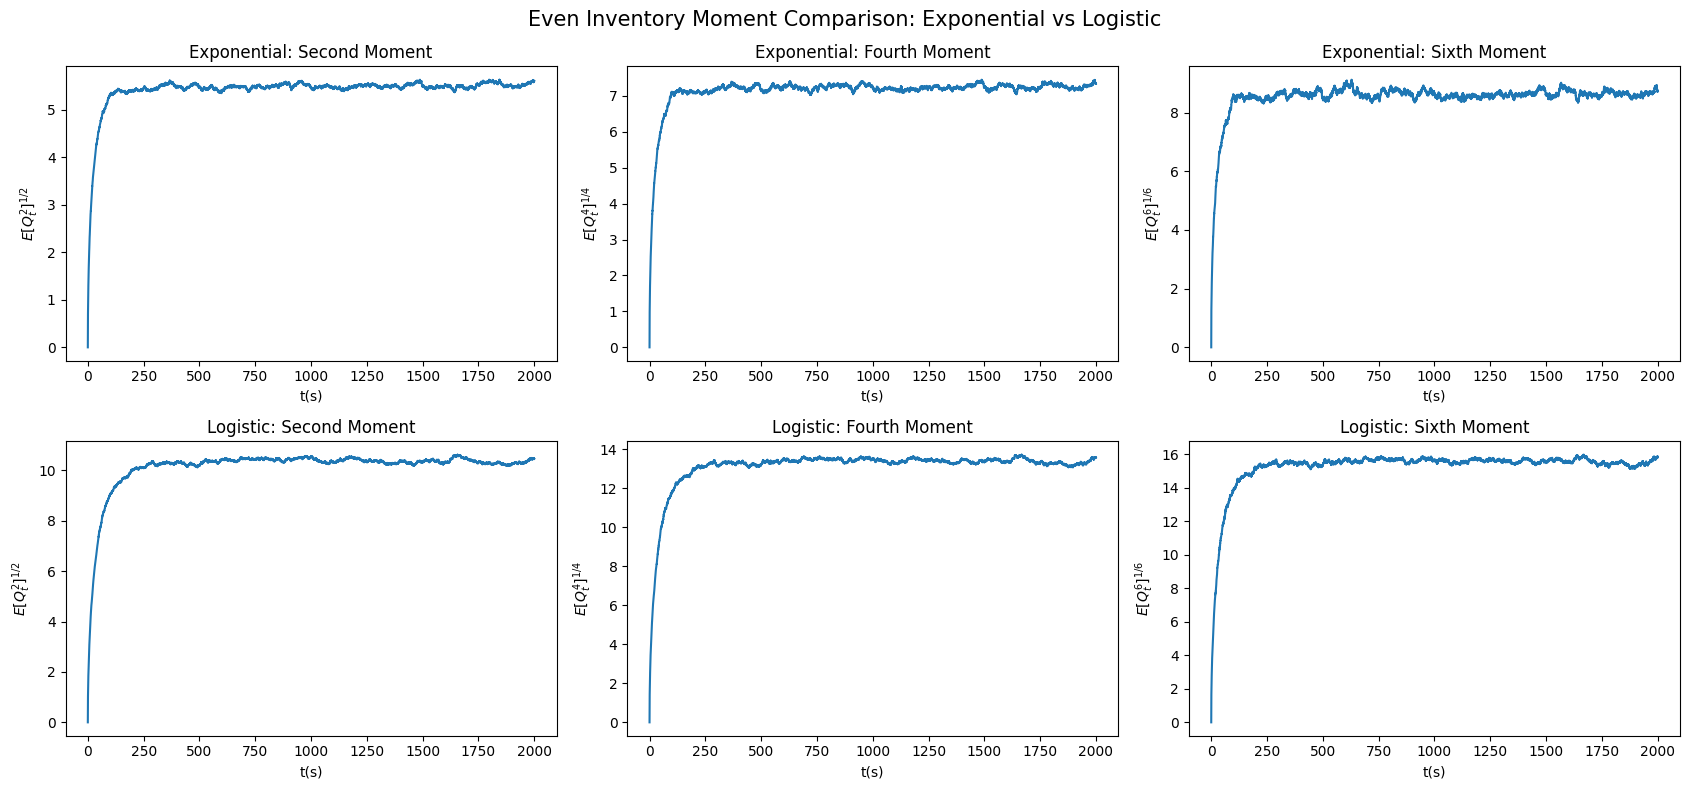

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8), sharex=False)


ax[0, 0].plot(ts_exp, np.mean(inv_exp**2, axis=0)**0.5)
ax[0, 0].set_xlabel("t(s)")
ax[0, 0].set_ylabel(r"$E[Q_t^2]^{1/2}$")
ax[0, 0].set_title("Exponential: Second Moment")

ax[0, 1].plot(ts_exp, np.mean(inv_exp**4, axis=0)**(1/4))
ax[0, 1].set_xlabel("t(s)")
ax[0, 1].set_ylabel(r"$E[Q_t^4]^{1/4}$")
ax[0, 1].set_title("Exponential: Fourth Moment")

ax[0, 2].plot(ts_exp, np.mean(inv_exp**6, axis=0)**(1/6))
ax[0, 2].set_xlabel("t(s)")
ax[0, 2].set_ylabel(r"$E[Q_t^6]^{1/6}$")
ax[0, 2].set_title("Exponential: Sixth Moment")

ax[1, 0].plot(ts_log, np.mean(inv_log**2, axis=0)**0.5)
ax[1, 0].set_xlabel("t(s)")
ax[1, 0].set_ylabel(r"$E[Q_t^2]^{1/2}$")
ax[1, 0].set_title("Logistic: Second Moment")

ax[1, 1].plot(ts_log, np.mean(inv_log**4, axis=0)**(1/4))
ax[1, 1].set_xlabel("t(s)")
ax[1, 1].set_ylabel(r"$E[Q_t^4]^{1/4}$")
ax[1, 1].set_title("Logistic: Fourth Moment")

ax[1, 2].plot(ts_log, np.mean(inv_log**6, axis=0)**(1/6))
ax[1, 2].set_xlabel("t(s)")
ax[1, 2].set_ylabel(r"$E[Q_t^6]^{1/6}$")
ax[1, 2].set_title("Logistic: Sixth Moment")

fig.suptitle("Even Inventory Moment Comparison: Exponential vs Logistic", fontsize=15)

plt.tight_layout()
plt.savefig("Even_moments_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
Q_exp = np.zeros((q_upper - q_lower + 1, q_upper - q_lower + 1))

for i in range(1, q_upper - q_lower):
    for j in range(q_upper - q_lower + 1):
        if j == i:
            Q_exp[i, j] = (
                - lambda_buy * np.exp(-kappa * delta_sell[q_upper - q_lower - 1 - i])
                - lambda_sell * np.exp(-kappa * delta_buy[q_upper - q_lower - i])
            )
        elif j == i + 1:
            Q_exp[i, j] = lambda_buy * np.exp(-kappa * delta_sell[q_upper - q_lower - 1 - i])
        elif j == i - 1:
            Q_exp[i, j] = lambda_sell * np.exp(-kappa * delta_buy[q_upper - q_lower - i])

Q_exp[0, 0] = - lambda_buy * np.exp(-kappa * delta_sell[q_upper - q_lower - 1])
Q_exp[0, 1] = lambda_buy * np.exp(-kappa * delta_sell[q_upper - q_lower - 1])

Q_exp[q_upper - q_lower, q_upper - q_lower] = - lambda_sell * np.exp(-kappa * delta_buy[0])
Q_exp[q_upper - q_lower, q_upper - q_lower - 1] = lambda_sell * np.exp(-kappa * delta_buy[0])

IndexError: index 59 is out of bounds for axis 0 with size 51

In [18]:
Q_log = np.zeros((q_upper - q_lower + 1, q_upper - q_lower + 1))

for i in range(1, q_upper - q_lower):
    for j in range(q_upper - q_lower + 1):
        if j == i:
            Q_log[i, j] = (
                - lambda_buy / (1 + np.exp(a_log + b_log * delta_sell[q_upper - q_lower - 1 - i]))
                - lambda_sell / (1 + np.exp(a_log + b_log * delta_buy[q_upper - q_lower - i]))
            )
        elif j == i + 1:
            Q_log[i, j] = lambda_buy / (1 + np.exp(a_log + b_log * delta_sell[q_upper - q_lower - 1 - i]))
        elif j == i - 1:
            Q_log[i, j] = lambda_sell / (1 + np.exp(a_log + b_log * delta_buy[q_upper - q_lower - i]))

Q_log[0, 0] = - lambda_buy / (1 + np.exp(a_log + b_log * delta_sell[q_upper - q_lower - 1]))
Q_log[0, 1] = lambda_buy / (1 + np.exp(a_log + b_log * delta_sell[q_upper - q_lower - 1]))

Q_log[q_upper - q_lower, q_upper - q_lower] = - lambda_sell / (1 + np.exp(a_log + b_log * delta_buy[0]))
Q_log[q_upper - q_lower, q_upper - q_lower - 1] = lambda_sell / (1 + np.exp(a_log + b_log * delta_buy[0]))

In [19]:
def compute_stationary_distribution(Q):
    n = Q.shape[0]
    # Transpose the matrix Q
    Q_T = Q.T
    # Replace the last row with ones to enforce the normalization condition
    A = Q_T.copy()
    A[-1, :] = 1
    # Create the right-hand side vector with the last element as 1
    b = np.zeros(n)
    b[-1] = 1
    # Solve the linear system
    pi = np.linalg.solve(A, b)
    return pi

# calculate the stationary distribution
pi_exp = compute_stationary_distribution(Q_exp)  # for exponential
pi_log = compute_stationary_distribution(Q_log)  # for logistic



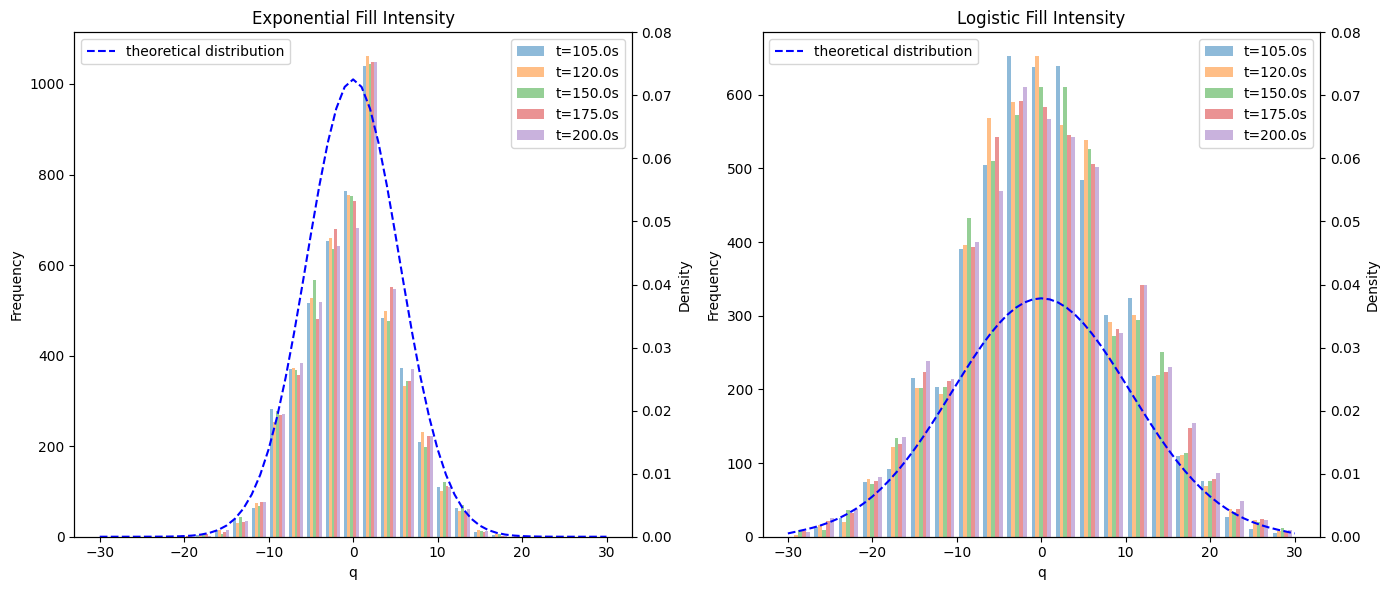

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# indices of time steps to plot
indices = [1050, 1200, 1500, 1750, 2000]
# Correctly define ts_exp and ts_log for plotting, matching simulation data
ts_exp_for_plot = np.arange(0, T_exp + ts_size_exp, ts_size_exp)
ts_log_for_plot = np.arange(0, T_log + ts_size_log, ts_size_log)
labels_exp = [f"t={ts_exp_for_plot[idx]:.1f}s" for idx in indices]
labels_log = [f"t={ts_log_for_plot[idx]:.1f}s" for idx in indices]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Exponential model distribution
ax[0].hist([inv_exp[:, idx] for idx in indices], bins=21, alpha=0.5, label=labels_exp)
ax[0].set_xlabel("q")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Exponential Fill Intensity")
ax2_exp = ax[0].twinx()
ax2_exp.plot(np.arange(q_lower, q_upper+1, 1), pi_exp, '--', color='blue', label='theoretical distribution')
ax2_exp.set_ylim(0, 0.08)
ax2_exp.set_ylabel("Density")
ax2_exp.legend(loc=2)
ax[0].legend()

# Logistic model distribution
ax[1].hist([inv_log[:, idx] for idx in indices], bins=21, alpha=0.5, label=labels_log)
ax[1].set_xlabel("q")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Logistic Fill Intensity")
ax2_log = ax[1].twinx()
ax2_log.plot(np.arange(q_lower, q_upper+1, 1), pi_log, '--', color='blue', label='theoretical distribution')
ax2_log.set_ylim(0, 0.08)
ax2_log.set_ylabel("Density")
ax2_log.legend(loc=2)
ax[1].legend()

plt.tight_layout()
plt.savefig("Inventory_distribution_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
from lib.ECP import ErgodicCP
import numpy as np


# Logistic fill intensity

a_log = -2
b_log = 10

def transition_m_log(q_upper, q_lower, lambda_buy, lambda_sell, kappa):
    P = np.zeros([q_upper - q_lower + 1, q_upper - q_lower + 1])
    control = ErgodicCP(
        lambda_buy=lambda_buy,
        lambda_sell=lambda_sell,
        q_upper=q_upper,
        q_lower=q_lower,
        phi=1e-5,
        kappa=kappa,
    ).EControl

    for i in range(1, q_upper - q_lower):
        for j in range(q_upper - q_lower + 1):
            sell_int = lambda_buy / (1 + np.exp(a_log + b_log * control[0][q_upper - q_lower - 1 - i]))
            buy_int  = lambda_sell / (1 + np.exp(a_log + b_log * control[1][q_upper - q_lower - i]))
            if j == i:
                P[i, j] = 1 - sell_int - buy_int + 2 * sell_int * buy_int
            elif j == i + 1:
                P[i, j] = sell_int * (1 - buy_int)
            elif j == i - 1:
                P[i, j] = buy_int * (1 - sell_int)

    sell0 = lambda_buy / (1 + np.exp(a_log + b_log * control[0][q_upper - q_lower - 1]))
    buy0  = lambda_sell / (1 + np.exp(a_log + b_log * control[1][0]))
    P[0, 0] = 1 - sell0
    P[0, 1] = sell0
    P[q_upper - q_lower, q_upper - q_lower] = 1 - buy0
    P[q_upper - q_lower, q_upper - q_lower - 1] = buy0

    return P


# Exponential fill intensity

def transition_m_exp(q_upper, q_lower, lambda_buy, lambda_sell, kappa):
    P = np.zeros([q_upper - q_lower + 1, q_upper - q_lower + 1])
    control = ErgodicCP(
        lambda_buy=lambda_buy,
        lambda_sell=lambda_sell,
        q_upper=q_upper,
        q_lower=q_lower,
        phi=1e-5,
        kappa=kappa,
    ).EControl

    for i in range(1, q_upper - q_lower):
        for j in range(q_upper - q_lower + 1):
            sell_int = lambda_buy * np.exp(-kappa * control[0][q_upper - q_lower - 1 - i])
            buy_int  = lambda_sell * np.exp(-kappa * control[1][q_upper - q_lower - i])
            if j == i:
                P[i, j] = -sell_int - buy_int + 2 * sell_int * buy_int + 1
            elif j == i + 1:
                P[i, j] = sell_int * (1 - buy_int)
            elif j == i - 1:
                P[i, j] = buy_int * (1 - sell_int)

    sell0 = lambda_buy * np.exp(-kappa * control[0][q_upper - q_lower - 1])
    buy0  = lambda_sell * np.exp(-kappa * control[1][0])
    P[0, 0] = 1 - sell0
    P[0, 1] = sell0
    P[q_upper - q_lower, q_upper - q_lower] = 1 - buy0
    P[q_upper - q_lower, q_upper - q_lower - 1] = buy0

    return P


# Common parameters

q_upper = 30
q_lower = -30
lambda_buy = 1
lambda_sell = 1
kappa = 10
n_steps = 2000

# Logistic transition matrix and TV
P_log = transition_m_log(q_upper, q_lower, lambda_buy, lambda_sell, kappa)
initial_state1_log = np.ones(q_upper - q_lower + 1) / (q_upper - q_lower + 1)
initial_state2_log = np.zeros(q_upper - q_lower + 1)
initial_state2_log[q_upper] = 1
distance_state_log = [np.linalg.norm(initial_state1_log - initial_state2_log, ord=1)]
for step in range(1, n_steps):
    state1 = initial_state1_log @ np.linalg.matrix_power(P_log, step)
    state2 = initial_state2_log @ np.linalg.matrix_power(P_log, step)
    distance_state_log.append(np.linalg.norm(state1 - state2, ord=1))

# Exponential transition matrix and TV
P_exp = transition_m_exp(q_upper, q_lower, lambda_buy, lambda_sell, kappa)
initial_state1_exp = np.ones(q_upper - q_lower + 1) / (q_upper - q_lower + 1)
initial_state2_exp = np.zeros(q_upper - q_lower + 1)
initial_state2_exp[q_upper] = 1
distance_state_exp = [np.linalg.norm(initial_state1_exp - initial_state2_exp, ord=1)]
for step in range(1, n_steps):
    state1 = initial_state1_exp @ np.linalg.matrix_power(P_exp, step)
    state2 = initial_state2_exp @ np.linalg.matrix_power(P_exp, step)
    distance_state_exp.append(np.linalg.norm(state1 - state2, ord=1))

/content/ECP.py:115: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(inventory[1:], delta_sell, 'o',label='sell depth $\delta^{+}$')
/content/ECP.py:116: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(inventory[:-1], delta_buy, 'o',label='buy depth $\delta^{-}$')
/content/ECP.py:118: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$\delta^{\pm}(\$)$')
/content/ECP.py:119: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Optimal Strategy $\delta^{\pm, *}(q)$ for Ergodic Control Problem")


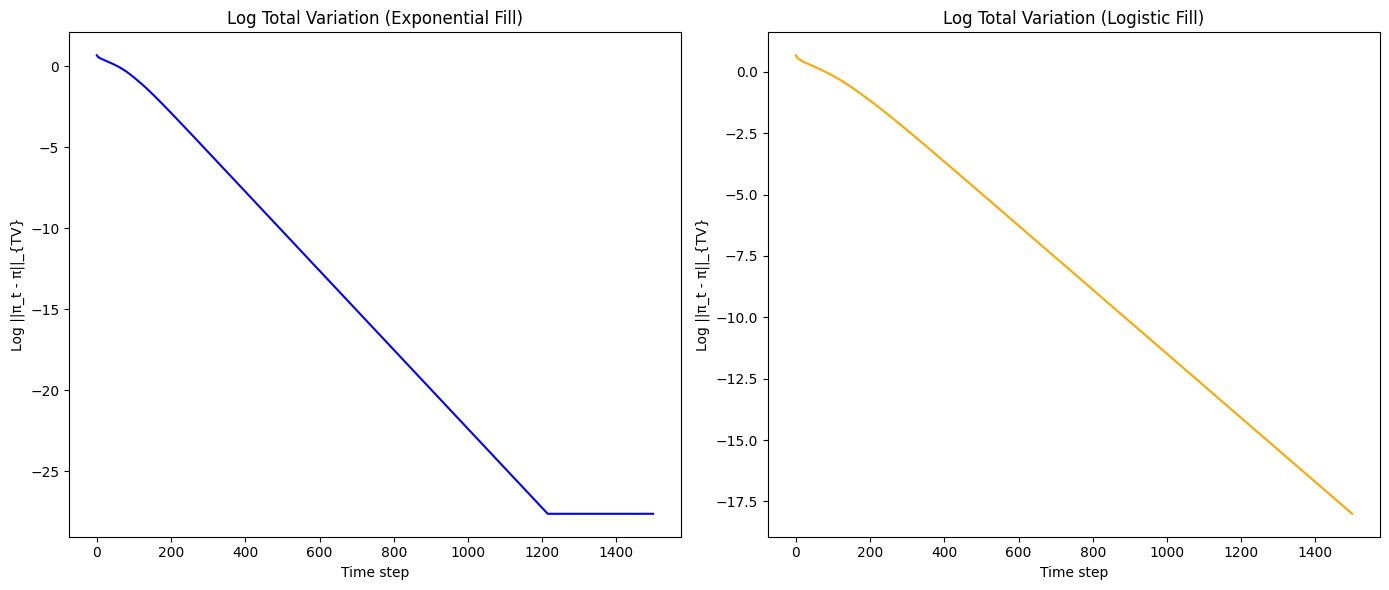

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the time axis
ts_log = np.arange(0, n_steps)
ts_exp = np.arange(0, n_steps)

# Logistic on right, exponential on left
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Exponential total variation → left
ax[0].plot(ts_exp[:1500], np.log(np.maximum(distance_state_exp[:1500], 1e-12)), color='blue')
ax[0].set_title("Log Total Variation (Exponential Fill)")
ax[0].set_xlabel("Time step")
ax[0].set_ylabel("Log ||π_t - π||_{TV}")

# Logistic total variation → right
ax[1].plot(ts_log[:1500], np.log(np.maximum(distance_state_log[:1500], 1e-12)), color='orange')
ax[1].set_title("Log Total Variation (Logistic Fill)")
ax[1].set_xlabel("Time step")
ax[1].set_ylabel("Log ||π_t - π||_{TV}")

plt.tight_layout()
plt.savefig("tv_distance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(P_exp, cmap='viridis', annot=False, cbar=True)
plt.xlabel("Next inventory state")
plt.ylabel("Current inventory state")
plt.title("Optimal Inventory Transition Matrix (P*): expoential fill")
plt.show()

NameError: name 'P_exp' is not defined

<Figure size 1000x800 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(P_log, cmap='viridis', annot=False, cbar=True)
plt.xlabel("Next inventory state")
plt.ylabel("Current inventory state")
plt.title("Optimal Inventory Transition Matrix (P*): logistic fill")
plt.show()

In [3]:
from lib.ECP import ErgodicCP_logisticfill

lambda_buy = 0.4
lambda_sell = 0.4

q_upper = 30
q_lower = -30

phi = 1e-6        # inventory risk penalty
a = -2            # logistic parameters
b = 10

alpha = 0.1       # terminal inventory penalty

x = 0             # initial cash
S = 100          # midprice

solver = ErgodicCP_logisticfill(
    lambda_buy,
    lambda_sell,
    q_upper,
    q_lower,
    phi,
    a,
    b,
    alpha,
    x,
    S
)

T:500
Difference:20.04838950245416
T:700
Difference:4.0031605040614755
T:900
Difference:1.7144828689669689
T:1100
Difference:0.9526158023377236
T:1300
Difference:0.6071537211015317
T:1500
Difference:0.41978762701090266
T:1700
Difference:0.3098556935291161
T:1900
Difference:0.23675001470330437
T:2100
Difference:0.18677629505147308
T:2300
Difference:0.15106714753143025
T:2500
Difference:0.1246792118178146
T:2700
Difference:0.10460059397116006
T:2900
Difference:0.08897719028801165
T:3100
Difference:0.07669221793668823
T:3300
Difference:0.06691777216535999
T:3500
Difference:0.05896084583024186
T:3700
Difference:0.05236551631374109
T:3900
Difference:0.046852981274355776
T:4100
Difference:0.04220137482749786


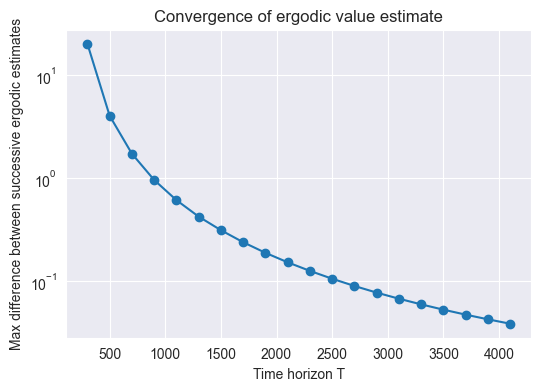

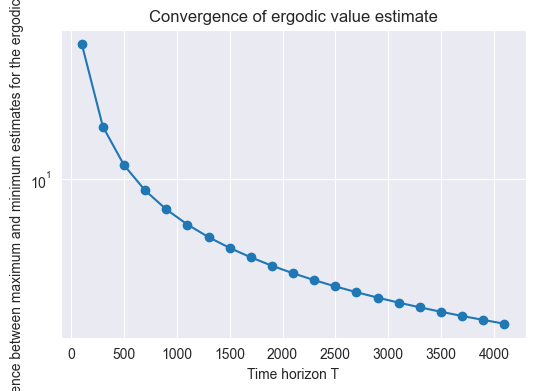

In [33]:
T_eval, ergodic_values, q_grid = solver.Ergodic_limit(T_start= 100, T_inc = 200, N_per_t=50, tol=1e-4)

import numpy as np
import matplotlib.pyplot as plt

ergodic_values = np.array(ergodic_values)

# compute successive differences
# differences between consecutive T values
diff_T = np.diff(ergodic_values, axis=0)  # shape (n_T-1, n_q)

# max absolute difference across q for each timestep
max_diff_per_T = np.max(np.abs(diff_T), axis=1)

spread_per_T = np.max(ergodic_values, axis=1) - np.min(ergodic_values, axis=1)

plt.figure(figsize=(6,4))
plt.plot(T_eval[1:], max_diff_per_T, marker='o')
plt.yscale("log")

plt.xlabel("Time horizon T")
plt.ylabel("Max difference between successive ergodic estimates")
plt.title("Convergence of ergodic value estimate")
plt.grid(True)

plt.show()

plt.figure(figsize=(6,4))
plt.plot(T_eval, spread_per_T, marker='o')
plt.yscale("log")

plt.xlabel("Time horizon T")
plt.ylabel("Difference between maximum and minimum estimates for the ergodic constant")
plt.title("Convergence of ergodic value estimate")
plt.grid(True)

plt.show()


mean est: 0.07107434986158481


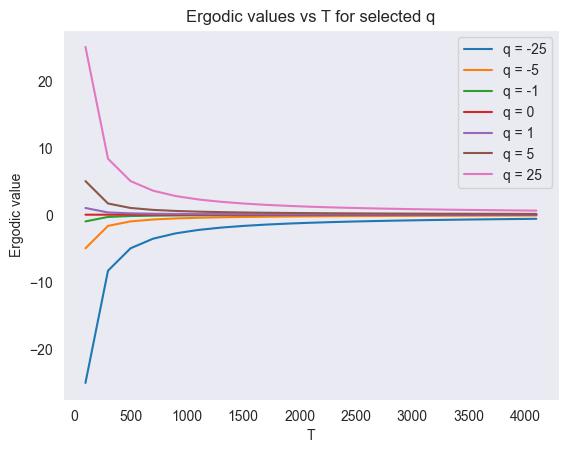

In [11]:
import numpy as np
import matplotlib.pyplot as plt

ergodic_values = np.array(ergodic_values)
q_grid = np.array(q_grid)

# q values to plot
q_targets = [-25, -5, -1, 0, 1, 5, 25]

plt.figure()
T_eval_cut = T_eval[0:]
ergodic_cut  = ergodic_values[0:]

ergodic_constant_est = np.mean(ergodic_cut[-1, :])
print("mean est: " + str(ergodic_constant_est))

for q in q_targets:
    # find index of closest q in grid
    idx = np.argmin(np.abs(q_grid - q))

    plt.plot(
        T_eval_cut,
        ergodic_cut[:, idx],
        label=f'q = {q_grid[idx]}'
    )

plt.xlabel('T')
plt.ylabel('Ergodic value')
plt.title('Ergodic values vs T for selected q')
plt.legend()
plt.grid()

plt.show()